test
# Latent DenseAM / oscillator score model toy experiment in JAX

This notebook implements the two-dimensional experiment described in your screenshot.  It trains and compares:

1. a **visible-only polynomial oscillator energy**;
2. a **binary hidden free-energy model** with fast latent units;
3. a **categorical DenseAM / prototype model** with softmax latent assignments;
4. a **neural score-network baseline** trained with the same denoising force target.

The training rule used throughout is **Denoising force matching: the cleanest on-device rule**.  It avoids the score-matching Hessian and avoids infinitesimal nudging.  At training time, the visible coordinates are clamped to a fully specified noisy point, hidden units are equilibrated if present, the model force is measured, and the measured force is matched to the known denoising force induced by the forward noising process.



## Mathematical setup

Forward noising uses the Ornstein--Uhlenbeck SDE

\[
    dx = -x\,dt + \sqrt{2 k_B T}\,dw.
\]

For a clean sample \(x_0\), the finite-time corruption is

\[
    x_t = a_t x_0 + \sigma_t \epsilon,
    \qquad a_t=e^{-t},
    \qquad \sigma_t^2=k_B T(1-e^{-2t}),
    \qquad \epsilon\sim\mathcal N(0,I).
\]

The conditional score of this Gaussian corruption kernel is known exactly:

\[
    \nabla_{x_t}\log p(x_t\mid x_0)
    = -\frac{x_t-a_t x_0}{\sigma_t^2}.
\]

The **denoising force target** is therefore

\[
    f^\star(x_t,x_0,t)
    = k_BT\,\nabla_{x_t}\log p(x_t\mid x_0)
    = -\frac{k_BT}{\sigma_t^2}(x_t-a_t x_0).
\]

For an energy model \(E_\theta^b(x,t)\), the learned physical force is

\[
    f_\theta(x,t) = -\nabla_x E_\theta^b(x,t),
    \qquad \frac{f_\theta(x,t)}{k_BT} \approx \nabla_x \log p_t(x).
\]

The denoising force-matching objective at each time slice is

\[
    \mathcal L_t(\theta)
    = \frac12\,\mathbb E_{x_0,\epsilon}
      \left\| f_\theta(x_t,t)-f^\star(x_t,x_0,t) \right\|^2.
\]

At inference, the reverse OU SDE is integrated as

\[
    dx = \left[x + 2 f_\theta(x,s)\right]dr + \sqrt{2k_BT}\,dw,
    \qquad s=\tau-r,
\]

starting from \(x\sim\mathcal N(0,k_BT I)\).  In the physical oscillator notation, the total reverse-time force is \(-\nabla E_\theta(x,s)=x+2f_\theta(x,s)\).


In [2]:

# Core imports
import math
import time
from functools import partial
from typing import Callable, Dict, List, Tuple

import numpy as np
import jax
import jax.numpy as jnp
from jax import random
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt

# Keep float32 unless you explicitly want higher precision.
jax.config.update("jax_enable_x64", False)

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())


JAX version: 0.4.33
Devices: [CudaDevice(id=0)]



## Configuration

The default settings are deliberately moderate.  They should run on CPU, but the full comparison still involves several independent time-slice trainings.  Increase the `RESEARCH_MODE` settings for cleaner figures.


In [3]:

# -----------------------------
# User-facing experiment knobs
# -----------------------------
SEED = 0
DATASET = "mog8"     # one of: "mog8", "ring", "moons"
RESEARCH_MODE = False

if RESEARCH_MODE:
    N_TRAIN = 4096
    N_TIME = 24
    STEPS_PER_TIME = 600
    MLP_STEPS = 6000
    BATCH_SIZE = 512
    N_REVERSE_STEPS = 300
    N_SAMPLES = 2000
else:
    N_TRAIN = 1536
    N_TIME = 14
    STEPS_PER_TIME = 220
    MLP_STEPS = 2500
    BATCH_SIZE = 256
    N_REVERSE_STEPS = 220
    N_SAMPLES = 1000

# Physical/noising parameters
kBT = 1.0
TAU = 2.5
T_MIN = 2e-2  # avoid the singular empirical score at exactly t=0
TIME_GRID = jnp.linspace(T_MIN, TAU, N_TIME)

# Model sizes
N_BINARY_HIDDEN = 48
N_CATEGORICAL_PROTOTYPES = 64
MLP_WIDTH = 96
MLP_DEPTH = 3

# Optimisation
LR_POLY = 3e-3
LR_BINARY = 2e-3
LR_CAT = 2e-3
LR_MLP = 2e-3
GRAD_CLIP = 10.0
REG_SCALE = 1e-6

# Plot / exact-score settings
GRID_LIM = 3.2
GRID_N = 120
SCORE_TEST_N = 512

key = random.PRNGKey(SEED)


2026-05-19 13:10:51.680140: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.



## Small PyTree Adam optimiser

This avoids an `optax` dependency.  The models below are JAX PyTrees composed of dictionaries and arrays.


In [4]:

def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)


def tree_sqnorm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.array(0.0)
    return sum([jnp.sum(jnp.square(x)) for x in leaves])


def tree_l2norm(tree):
    return jnp.sqrt(tree_sqnorm(tree) + 1e-12)


def clip_tree(tree, max_norm):
    norm = tree_l2norm(tree)
    scale = jnp.minimum(1.0, max_norm / (norm + 1e-12))
    return jax.tree_util.tree_map(lambda x: x * scale, tree)


def adam_init(params):
    return {"m": tree_zeros_like(params), "v": tree_zeros_like(params), "t": jnp.array(0, dtype=jnp.int32)}


def adam_step(params, state, grads, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    t = state["t"] + 1
    m = jax.tree_util.tree_map(lambda m, g: beta1 * m + (1.0 - beta1) * g, state["m"], grads)
    v = jax.tree_util.tree_map(lambda v, g: beta2 * v + (1.0 - beta2) * jnp.square(g), state["v"], grads)
    m_hat = jax.tree_util.tree_map(lambda m: m / (1.0 - beta1 ** t), m)
    v_hat = jax.tree_util.tree_map(lambda v: v / (1.0 - beta2 ** t), v)
    params = jax.tree_util.tree_map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps), params, m_hat, v_hat)
    return params, {"m": m, "v": v, "t": t}



## Toy data distributions

The notebook supports the three suggested two-dimensional datasets.  `mog8` is the easiest for discrete mode-coverage metrics.  `ring` is closest to the DenseAM/diffusion toy derivation.  `moons` tests nonconvex manifold coverage.


Dataset: mog8 train_data shape: (1536, 2)


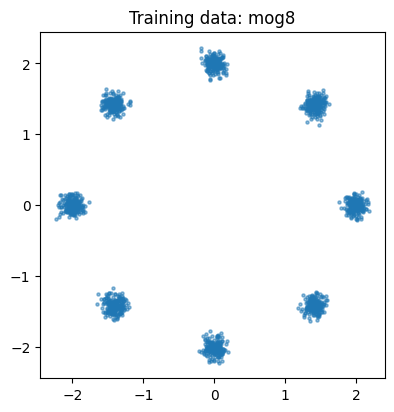

In [5]:

def make_mog8_centers(radius=2.0):
    angles = jnp.linspace(0.0, 2.0 * jnp.pi, 8, endpoint=False)
    return radius * jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=1)


def sample_mog8(key, n, radius=2.0, sigma=0.08):
    k_idx, k_eps = random.split(key)
    centers = make_mog8_centers(radius)
    idx = random.randint(k_idx, (n,), minval=0, maxval=centers.shape[0])
    x = centers[idx] + sigma * random.normal(k_eps, (n, 2))
    meta = {"kind": "mog8", "centers": centers, "sigma": sigma}
    return x, meta


def sample_ring(key, n, radius=1.7, radial_sigma=0.045):
    k_theta, k_r = random.split(key)
    theta = random.uniform(k_theta, (n,), minval=0.0, maxval=2.0 * jnp.pi)
    r = radius + radial_sigma * random.normal(k_r, (n,))
    x = jnp.stack([r * jnp.cos(theta), r * jnp.sin(theta)], axis=1)
    meta = {"kind": "ring", "radius": radius, "n_bins": 36}
    return x, meta


def moon_reference(n_per_moon=40):
    th = jnp.linspace(0.0, jnp.pi, n_per_moon)
    m1 = jnp.stack([jnp.cos(th), jnp.sin(th)], axis=1)
    m2 = jnp.stack([1.0 - jnp.cos(th), -jnp.sin(th) - 0.55], axis=1)
    ref = jnp.concatenate([m1, m2], axis=0)
    ref = 1.35 * (ref - jnp.mean(ref, axis=0, keepdims=True))
    return ref


def sample_moons(key, n, noise=0.055):
    k_sel, k_theta, k_eps, k_perm = random.split(key, 4)
    is_second = random.bernoulli(k_sel, 0.5, (n,))
    th = random.uniform(k_theta, (n,), minval=0.0, maxval=jnp.pi)
    m1 = jnp.stack([jnp.cos(th), jnp.sin(th)], axis=1)
    m2 = jnp.stack([1.0 - jnp.cos(th), -jnp.sin(th) - 0.55], axis=1)
    x = jnp.where(is_second[:, None], m2, m1)
    x = 1.35 * (x - jnp.array([[0.5, 0.225]]))
    x = x + noise * random.normal(k_eps, (n, 2))
    perm = random.permutation(k_perm, n)
    x = x[perm]
    meta = {"kind": "moons", "reference": moon_reference(50)}
    return x, meta


def make_dataset(key, kind, n):
    if kind == "mog8":
        return sample_mog8(key, n)
    if kind == "ring":
        return sample_ring(key, n)
    if kind == "moons":
        return sample_moons(key, n)
    raise ValueError(f"Unknown dataset kind: {kind}")


key, sub = random.split(key)
train_data, data_meta = make_dataset(sub, DATASET, N_TRAIN)
print("Dataset:", data_meta["kind"], "train_data shape:", train_data.shape)

plt.figure(figsize=(4.5, 4.5))
plt.scatter(np.array(train_data[:, 0]), np.array(train_data[:, 1]), s=5, alpha=0.5)
plt.gca().set_aspect("equal")
plt.title(f"Training data: {DATASET}")
plt.show()



## OU corruption and exact empirical score

`corrupt_ou` produces the noisy sample and the denoising-force target.  `empirical_force` computes the exact force of the finite empirical Gaussian mixture induced by the training set.  The latter is used only for evaluation and oracle plots, not for training.


In [6]:

def _expand_time_scalar_or_batch(v, x):
    # Broadcast scalar or shape-(B,) time coefficients to match x with shape (B, D).
    v = jnp.asarray(v)
    if v.ndim == 0:
        return v
    return v[:, None]


def ou_coeffs(t, kBT=1.0):
    a = jnp.exp(-t)
    sigma2 = kBT * (1.0 - a * a)
    sigma2 = jnp.maximum(sigma2, 1e-6)
    return a, sigma2


def corrupt_ou(key, x0, t, kBT=1.0):
    eps = random.normal(key, x0.shape)
    a, sigma2 = ou_coeffs(t, kBT)
    a_b = _expand_time_scalar_or_batch(a, x0)
    s2_b = _expand_time_scalar_or_batch(sigma2, x0)
    xt = a_b * x0 + jnp.sqrt(s2_b) * eps
    target_force = -kBT * (xt - a_b * x0) / s2_b
    return xt, target_force


@partial(jax.jit, static_argnums=(3,))
def empirical_force(x, t, data, max_data=None, kBT=1.0):
    # Exact kBT * score of the empirical OU-smoothed data distribution at scalar t.
    if max_data is not None:
        data = data[:max_data]
    a, sigma2 = ou_coeffs(t, kBT)
    diff = x[:, None, :] - a * data[None, :, :]
    logits = -jnp.sum(diff * diff, axis=-1) / (2.0 * sigma2)
    w = jax.nn.softmax(logits, axis=1)
    posterior_mean = jnp.sum(w[:, :, None] * (a * data[None, :, :]), axis=1)
    return kBT * (posterior_mean - x) / sigma2


@partial(jax.jit, static_argnums=(3,))
def empirical_energy(x, t, data, max_data=None, kBT=1.0):
    # Unnormalised Eb(x,t) = -kBT log p_t(x), up to x-independent constants.
    if max_data is not None:
        data = data[:max_data]
    a, sigma2 = ou_coeffs(t, kBT)
    diff = x[:, None, :] - a * data[None, :, :]
    logits = -jnp.sum(diff * diff, axis=-1) / (2.0 * sigma2)
    return -kBT * logsumexp(logits, axis=1)



## Model 1: visible-only polynomial oscillator energy

This is a two-oscillator version of the polynomial local-plus-coupling energy.  The sixth-order local term is constrained positive for coercivity; lower-order and asymmetric terms are trainable.


In [7]:

def init_poly(key, data=None):
    k1, k2, k3 = random.split(key, 3)
    return {
        "lin": 0.01 * random.normal(k1, (2,)),
        "alpha": jnp.ones((2,)),               # near Gaussian force -x at large t
        "beta": 0.02 * random.normal(k2, (2,)),
        "gamma_raw": -3.0 * jnp.ones((2,)),    # softplus -> small positive sixth-order term
        "kappa": jnp.array(0.0),
        "lambda": jnp.array(0.0),
        "chi": 0.01 * random.normal(k3, (2,)), # x1*x2^2 and x1^2*x2
    }


def poly_energy_single(params, x):
    x1, x2 = x[0], x[1]
    gamma = jax.nn.softplus(params["gamma_raw"]) + 1e-4
    local = (
        jnp.dot(params["lin"], x)
        + 0.5 * jnp.sum(params["alpha"] * x**2)
        + 0.25 * jnp.sum(params["beta"] * x**4)
        + (1.0 / 6.0) * jnp.sum(gamma * x**6)
    )
    d = x1 - x2
    coupling = (
        0.5 * params["kappa"] * d**2
        + 0.25 * params["lambda"] * d**4
        + params["chi"][0] * x1 * x2**2
        + params["chi"][1] * x1**2 * x2
    )
    return local + coupling


_poly_grad_x = jax.grad(poly_energy_single, argnums=1)


def poly_energy(params, x):
    return jax.vmap(lambda z: poly_energy_single(params, z))(x)


def poly_force(params, x):
    return -jax.vmap(lambda z: _poly_grad_x(params, z))(x)



## Model 2: binary hidden free-energy model

This model uses fast binary latent units.  The hidden units are conditionally independent given the visible coordinates.  The exact marginal free energy is

\[
F_\theta(x)
= \frac{a}{2}\lVert x\rVert^2 + \frac{g}{6}\sum_i x_i^6
- T_h \sum_j \log\left(1+\exp\left(\ell_j(x)/T_h\right)\right),
\]

where

\[
\ell_j(x)=b_j + \sum_i W_{ij}x_i + \sum_i V_{ij}x_i^2.
\]

The equilibrium hidden activation is \(h_j^\star=\sigma(\ell_j/T_h)\), and the visible force is local in the sense that each visible coordinate receives the sum of its connected hidden activations times local derivatives of the coupling features.


In [8]:

def init_binary_hidden(key, data=None, H=N_BINARY_HIDDEN):
    kW, kV, kb = random.split(key, 3)
    return {
        "W": 0.12 * random.normal(kW, (2, H)),
        "V": 0.025 * random.normal(kV, (2, H)),
        "b": 0.01 * random.normal(kb, (H,)),
        "log_base": jnp.array(0.0),    # softplus + offset
        "log_six": jnp.array(-5.0),
        "log_temp": jnp.array(-0.4),
    }


def binary_base(params):
    return jax.nn.softplus(params["log_base"]) + 0.05


def binary_six(params):
    return jax.nn.softplus(params["log_six"]) + 1e-5


def binary_temp(params):
    return jax.nn.softplus(params["log_temp"]) + 0.05


def binary_logits(params, x):
    return x @ params["W"] + (x**2) @ params["V"] + params["b"]


def binary_hidden_eq(params, x):
    return jax.nn.sigmoid(binary_logits(params, x) / binary_temp(params))


def binary_energy(params, x):
    base = binary_base(params)
    six = binary_six(params)
    temp = binary_temp(params)
    logits = binary_logits(params, x)
    visible = 0.5 * base * jnp.sum(x**2, axis=-1) + (six / 6.0) * jnp.sum(x**6, axis=-1)
    hidden_free = -temp * jnp.sum(jax.nn.softplus(logits / temp), axis=-1)
    return visible + hidden_free


def binary_force_given_h(params, x, h):
    base = binary_base(params)
    six = binary_six(params)
    # force_i = -base*x_i - six*x_i^5 + sum_j h_j (W_ij + 2 V_ij x_i)
    force = -base * x - six * x**5
    force = force + h @ params["W"].T
    force = force + 2.0 * x * (h @ params["V"].T)
    return force


def binary_force(params, x):
    return binary_force_given_h(params, x, binary_hidden_eq(params, x))



## Model 3: categorical DenseAM / prototype model

This is the log-sum-exp DenseAM energy with learned prototypes:

\[
E_\theta(x)=-\beta^{-1}\log\sum_{k=1}^K
\exp\left[-\frac{\beta}{2}\lVert x-c_k\rVert^2\right].
\]

Equivalently, a fast categorical latent unit selects a prototype softly:

\[
q_k^\star(x)=\operatorname{softmax}_k\left[-\frac{\beta}{2}\lVert x-c_k\rVert^2\right],
\qquad
f_\theta(x)=\sum_k q_k^\star(x)(c_k-x).
\]


In [9]:

def init_categorical_dam(key, data=None, K=N_CATEGORICAL_PROTOTYPES):
    k_idx, k_noise = random.split(key)
    if data is None:
        centers = 0.5 * random.normal(k_noise, (K, 2))
    else:
        idx = random.randint(k_idx, (K,), minval=0, maxval=data.shape[0])
        centers = data[idx] + 0.05 * random.normal(k_noise, (K, 2))
    return {
        "centers": centers,
        "log_beta": jnp.array(1.7),
    }


def cat_beta(params):
    return jax.nn.softplus(params["log_beta"]) + 0.05


def cat_logits(params, x):
    beta = cat_beta(params)
    c = params["centers"]
    dist2 = jnp.sum((x[:, None, :] - c[None, :, :]) ** 2, axis=-1)
    return -0.5 * beta * dist2


def cat_q_eq(params, x):
    return jax.nn.softmax(cat_logits(params, x), axis=-1)


def cat_energy(params, x):
    beta = cat_beta(params)
    return -logsumexp(cat_logits(params, x), axis=-1) / beta


def cat_force_given_q(params, x, q):
    return q @ params["centers"] - x


def cat_force(params, x):
    return cat_force_given_q(params, x, cat_q_eq(params, x))



## Model 4: neural score-network baseline

This is not an energy model and therefore does not have a guaranteed Lyapunov energy.  It is included as an unconstrained baseline trained with the same denoising force target.  The input is \((x_1,x_2,t/\tau,\sin(2\pi t/\tau),\cos(2\pi t/\tau))\), and the output is the force \(f_\theta(x,t)\approx k_BT\nabla_x\log p_t(x)\).


In [10]:

def glorot(key, fan_in, fan_out):
    lim = math.sqrt(6.0 / (fan_in + fan_out))
    return random.uniform(key, (fan_in, fan_out), minval=-lim, maxval=lim)


def init_mlp(key, width=MLP_WIDTH, depth=MLP_DEPTH):
    dims = [5] + [width] * depth + [2]
    keys = random.split(key, len(dims) - 1)
    layers = []
    for k, din, dout in zip(keys, dims[:-1], dims[1:]):
        layers.append({"W": glorot(k, din, dout), "b": jnp.zeros((dout,))})
    return {"layers": layers}


def time_features(t, batch_size):
    t = jnp.asarray(t)
    if t.ndim == 0:
        u = jnp.ones((batch_size, 1)) * (t / TAU)
    else:
        u = t[:, None] / TAU
    return jnp.concatenate([u, jnp.sin(2.0 * jnp.pi * u), jnp.cos(2.0 * jnp.pi * u)], axis=-1)


def mlp_force(params, x, t):
    h = jnp.concatenate([x, time_features(t, x.shape[0])], axis=-1)
    for layer in params["layers"][:-1]:
        h = jnp.tanh(h @ layer["W"] + layer["b"])
    out = h @ params["layers"][-1]["W"] + params["layers"][-1]["b"]
    return out



## Denoising force-matching training loops

For the three energy/free-energy models, we train separate time slices and initialise lower-noise slices from the previous higher-noise solution.  This is numerically stable because the high-noise target is close to the Gaussian force \(-x\).  It is also a natural protocol for physical devices: fix a noise time, clamp a noisy data point, equilibrate latent variables if present, measure the force, and update couplings.

The MLP baseline is trained over randomly sampled times in a single time-conditioned network.


In [11]:

def make_time_slice_loss(force_fn: Callable, batch_size: int, reg_scale: float, kBT: float):
    def loss_fn(params, key, data, t):
        k_idx, k_noise = random.split(key)
        idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        xt, target = corrupt_ou(k_noise, x0, t, kBT)
        pred = force_fn(params, xt)
        mse = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=-1))
        return mse + reg_scale * tree_sqnorm(params)
    return loss_fn


def train_time_slices(
    name: str,
    init_fn: Callable,
    force_fn: Callable,
    key,
    data,
    t_grid,
    steps_per_time: int,
    batch_size: int,
    lr: float,
    reg_scale: float = REG_SCALE,
    grad_clip: float = GRAD_CLIP,
):
    key, k_init = random.split(key)
    params = init_fn(k_init, data)
    params_by_idx = [None for _ in range(len(t_grid))]
    loss_fn = make_time_slice_loss(force_fn, batch_size, reg_scale, kBT)
    loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))

    # Train high-noise -> low-noise; store by forward-time index.
    t0_wall = time.time()
    for idx in list(range(len(t_grid) - 1, -1, -1)):
        opt_state = adam_init(params)
        t = t_grid[idx]
        last_loss = None
        for step in range(steps_per_time):
            key, sub = random.split(key)
            loss_val, grads = loss_and_grad(params, sub, data, t)
            grads = clip_tree(grads, grad_clip)
            params, opt_state = adam_step(params, opt_state, grads, lr=lr)
            last_loss = loss_val
        params_by_idx[idx] = params
        print(f"{name:>12s} | t={float(t):.3f} | loss={float(last_loss):.4e}")
    print(f"{name} finished in {time.time() - t0_wall:.1f}s")
    return params_by_idx, key


def make_mlp_loss(batch_size: int, reg_scale: float, kBT: float):
    def loss_fn(params, key, data):
        k_idx, k_t, k_noise = random.split(key, 3)
        idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        t = random.uniform(k_t, (batch_size,), minval=T_MIN, maxval=TAU)
        xt, target = corrupt_ou(k_noise, x0, t, kBT)
        pred = mlp_force(params, xt, t)
        mse = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=-1))
        return mse + reg_scale * tree_sqnorm(params)
    return loss_fn


def train_mlp_baseline(key, data, steps: int, batch_size: int, lr: float):
    key, k_init = random.split(key)
    params = init_mlp(k_init)
    opt_state = adam_init(params)
    loss_fn = make_mlp_loss(batch_size, REG_SCALE, kBT)
    loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))
    t0_wall = time.time()
    for step in range(steps):
        key, sub = random.split(key)
        loss_val, grads = loss_and_grad(params, sub, data)
        grads = clip_tree(grads, GRAD_CLIP)
        params, opt_state = adam_step(params, opt_state, grads, lr=lr)
        if step % max(1, steps // 10) == 0 or step == steps - 1:
            print(f"MLP | step={step:5d}/{steps} | loss={float(loss_val):.4e}")
    print(f"MLP finished in {time.time() - t0_wall:.1f}s")
    return params, key


In [12]:

# -----------------------------
# Train all four models
# -----------------------------
TRAIN_POLY = True
TRAIN_BINARY = True
TRAIN_CAT = True
TRAIN_MLP = True

trained = {}

if TRAIN_POLY:
    key, sub = random.split(key)
    trained["poly"], key = train_time_slices(
        "poly", init_poly, poly_force, sub, train_data, TIME_GRID,
        STEPS_PER_TIME, BATCH_SIZE, LR_POLY
    )

if TRAIN_BINARY:
    key, sub = random.split(key)
    trained["binary"], key = train_time_slices(
        "binary", init_binary_hidden, binary_force, sub, train_data, TIME_GRID,
        STEPS_PER_TIME, BATCH_SIZE, LR_BINARY
    )

if TRAIN_CAT:
    key, sub = random.split(key)
    trained["categorical"], key = train_time_slices(
        "categorical", init_categorical_dam, cat_force, sub, train_data, TIME_GRID,
        STEPS_PER_TIME, BATCH_SIZE, LR_CAT
    )

if TRAIN_MLP:
    key, sub = random.split(key)
    trained["mlp"], key = train_mlp_baseline(sub, train_data, MLP_STEPS, BATCH_SIZE, LR_MLP)


        poly | t=2.500 | loss=2.2947e-01
        poly | t=2.309 | loss=1.0758e-01
        poly | t=2.118 | loss=7.3118e-02
        poly | t=1.928 | loss=8.6843e-02
        poly | t=1.737 | loss=8.9033e-02
        poly | t=1.546 | loss=1.2247e-01
        poly | t=1.355 | loss=1.5773e-01
        poly | t=1.165 | loss=2.3038e-01
        poly | t=0.974 | loss=3.0740e-01
        poly | t=0.783 | loss=4.4674e-01
        poly | t=0.592 | loss=7.7122e-01
        poly | t=0.402 | loss=1.1199e+00
        poly | t=0.211 | loss=1.9667e+00
        poly | t=0.020 | loss=2.2789e+01
poly finished in 31.7s
      binary | t=2.500 | loss=4.3272e-02
      binary | t=2.309 | loss=2.2151e-02
      binary | t=2.118 | loss=3.2317e-02
      binary | t=1.928 | loss=4.4409e-02
      binary | t=1.737 | loss=6.3438e-02
      binary | t=1.546 | loss=9.3148e-02
      binary | t=1.355 | loss=1.3525e-01
      binary | t=1.165 | loss=1.9852e-01
      binary | t=0.974 | loss=2.8228e-01
      binary | t=0.783 | loss=3.91


## Reverse-time samplers

The energy models use the time-slice parameters nearest to the current reverse-time value.  For the binary and categorical latent models, there are two samplers:

* **equilibrium hidden units**: hidden variables are infinitely fast and always at \(h^\star(x,t)\) or \(q^\star(x,t)\);
* **finite hidden time scale**: hidden variables relax according to \(\dot h=(h^\star-h)/\tau_h\), exposing sensitivity to the hidden/visible time-scale ratio.


In [13]:

def nearest_time_idx(t, t_grid=TIME_GRID):
    return int(np.argmin(np.abs(np.asarray(t_grid) - float(t))))


def reverse_sample_time_slices(key, params_seq, force_fn, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS, clip_x=8.0):
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        idx = nearest_time_idx(s)
        params = params_seq[idx]
        f = force_fn(params, x)
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key


def reverse_sample_mlp(key, params, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS, clip_x=8.0):
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        t_batch = jnp.ones((n_samples,)) * s
        f = mlp_force(params, x, t_batch)
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key


def reverse_sample_binary_finite_hidden(
    key, params_seq, hidden_tau_ratio=0.05, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS, clip_x=8.0
):
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    params = params_seq[nearest_time_idx(TAU)]
    h = binary_hidden_eq(params, x)
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        params = params_seq[nearest_time_idx(s)]
        h_eq = binary_hidden_eq(params, x)
        if hidden_tau_ratio <= 0:
            h = h_eq
        else:
            alpha = 1.0 - math.exp(-dt / hidden_tau_ratio)
            h = h + alpha * (h_eq - h)
        f = binary_force_given_h(params, x, h)
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key


def reverse_sample_cat_finite_hidden(
    key, params_seq, hidden_tau_ratio=0.05, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS, clip_x=8.0
):
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    params = params_seq[nearest_time_idx(TAU)]
    q = cat_q_eq(params, x)
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        params = params_seq[nearest_time_idx(s)]
        q_eq = cat_q_eq(params, x)
        if hidden_tau_ratio <= 0:
            q = q_eq
        else:
            alpha = 1.0 - math.exp(-dt / hidden_tau_ratio)
            q = q + alpha * (q_eq - q)
            q = q / jnp.sum(q, axis=-1, keepdims=True)
        f = cat_force_given_q(params, x, q)
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key


In [14]:

# Generate samples from all trained models.
samples = {}

if "poly" in trained:
    key, sub = random.split(key)
    samples["poly"] , key = reverse_sample_time_slices(sub, trained["poly"], poly_force)

if "binary" in trained:
    key, sub = random.split(key)
    samples["binary_eq"], key = reverse_sample_time_slices(sub, trained["binary"], binary_force)

if "categorical" in trained:
    key, sub = random.split(key)
    samples["categorical_eq"], key = reverse_sample_time_slices(sub, trained["categorical"], cat_force)

if "mlp" in trained:
    key, sub = random.split(key)
    samples["mlp"], key = reverse_sample_mlp(sub, trained["mlp"])

print({name: x.shape for name, x in samples.items()})


{'poly': (1000, 2), 'binary_eq': (1000, 2), 'categorical_eq': (1000, 2), 'mlp': (1000, 2)}



## Metrics: mode/manifold coverage and score error

For `mog8`, coverage is the fraction of Gaussian modes receiving enough generated mass.  For `ring`, coverage is angular-bin coverage and radial RMSE.  For `moons`, coverage is the fraction of reference manifold bins covered.  Score error is the normalised RMSE against the exact empirical OU-smoothed score.


In [15]:

def coverage_metrics(samples_x, meta, min_frac=0.005):
    x = np.asarray(samples_x)
    n = x.shape[0]
    kind = meta["kind"]
    if kind == "mog8":
        centers = np.asarray(meta["centers"])
        d2 = ((x[:, None, :] - centers[None, :, :]) ** 2).sum(axis=-1)
        labels = d2.argmin(axis=1)
        counts = np.bincount(labels, minlength=centers.shape[0])
        threshold = max(2, int(min_frac * n))
        coverage = np.mean(counts >= threshold)
        probs = counts / max(1, counts.sum())
        uniform = np.ones_like(probs) / len(probs)
        kl_to_uniform = float(np.sum(np.where(probs > 0, probs * np.log(probs / uniform), 0.0)))
        mean_nearest_dist = float(np.mean(np.sqrt(d2.min(axis=1))))
        return {
            "coverage": float(coverage),
            "kl_to_uniform": kl_to_uniform,
            "mean_nearest_dist": mean_nearest_dist,
            "counts": counts,
        }
    if kind == "ring":
        theta = np.mod(np.arctan2(x[:, 1], x[:, 0]), 2.0 * np.pi)
        bins = meta.get("n_bins", 36)
        labels = np.floor(theta / (2.0 * np.pi) * bins).astype(int)
        counts = np.bincount(labels, minlength=bins)
        threshold = max(2, int(min_frac * n))
        coverage = np.mean(counts >= threshold)
        r = np.sqrt((x**2).sum(axis=1))
        radial_rmse = float(np.sqrt(np.mean((r - meta["radius"]) ** 2)))
        return {"coverage": float(coverage), "radial_rmse": radial_rmse, "counts": counts}
    if kind == "moons":
        ref = np.asarray(meta["reference"])
        d2 = ((x[:, None, :] - ref[None, :, :]) ** 2).sum(axis=-1)
        labels = d2.argmin(axis=1)
        counts = np.bincount(labels, minlength=ref.shape[0])
        threshold = max(1, int(min_frac * n))
        coverage = np.mean(counts >= threshold)
        mean_ref_dist = float(np.mean(np.sqrt(d2.min(axis=1))))
        return {"coverage": float(coverage), "mean_ref_dist": mean_ref_dist, "counts": counts}
    raise ValueError(kind)


def model_force_at_t(model_name, t, x):
    if model_name == "poly":
        return poly_force(trained["poly"][nearest_time_idx(t)], x)
    if model_name == "binary":
        return binary_force(trained["binary"][nearest_time_idx(t)], x)
    if model_name == "categorical":
        return cat_force(trained["categorical"][nearest_time_idx(t)], x)
    if model_name == "mlp":
        return mlp_force(trained["mlp"], x, jnp.ones((x.shape[0],)) * t)
    raise ValueError(model_name)


def score_error(model_name, key, data, t_values=(0.05, 0.15, 0.4, 1.0, 2.0), n=SCORE_TEST_N):
    out = []
    for t in t_values:
        if t < T_MIN or t > TAU:
            continue
        key, k_idx, k_noise = random.split(key, 3)
        idx = random.randint(k_idx, (n,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        xt, _ = corrupt_ou(k_noise, x0, t, kBT)
        f_exact = empirical_force(xt, t, data, min(2048, data.shape[0]), kBT)
        f_pred = model_force_at_t(model_name, t, xt)
        mse = jnp.mean(jnp.sum((f_pred - f_exact) ** 2, axis=-1))
        denom = jnp.mean(jnp.sum(f_exact**2, axis=-1)) + 1e-8
        out.append({"t": float(t), "nrmse": float(jnp.sqrt(mse / denom)), "mse": float(mse)})
    return out, key


# Print coverage metrics
for name, sx in samples.items():
    print("\n", name)
    for k, v in coverage_metrics(sx, data_meta).items():
        if k != "counts":
            print(f"  {k:>18s}: {v}")

# Print score errors for trained models
for model_name in ["poly", "binary", "categorical", "mlp"]:
    if (model_name in trained) or (model_name == "mlp" and "mlp" in trained):
        key, sub = random.split(key)
        errs, key = score_error(model_name, sub, train_data)
        print("\nscore error", model_name)
        for row in errs:
            print(f"  t={row['t']:.3f} | nRMSE={row['nrmse']:.3f} | MSE={row['mse']:.3e}")



 poly
            coverage: 1.0
       kl_to_uniform: 0.041044636587370203
   mean_nearest_dist: 0.6364820003509521

 binary_eq
            coverage: 1.0
       kl_to_uniform: 0.009892523529725649
   mean_nearest_dist: 0.7162075042724609

 categorical_eq
            coverage: 1.0
       kl_to_uniform: 0.00538705344556578
   mean_nearest_dist: 0.8762422800064087

 mlp
            coverage: 1.0
       kl_to_uniform: 0.02935234841056499
   mean_nearest_dist: 0.42909887433052063

score error poly
  t=0.050 | nRMSE=0.828 | MSE=1.144e+01
  t=0.150 | nRMSE=0.594 | MSE=1.457e+00
  t=0.400 | nRMSE=0.281 | MSE=1.419e-01
  t=1.000 | nRMSE=0.126 | MSE=2.717e-02
  t=2.000 | nRMSE=0.238 | MSE=1.064e-01

score error binary
  t=0.050 | nRMSE=0.869 | MSE=1.270e+01
  t=0.150 | nRMSE=0.711 | MSE=1.841e+00
  t=0.400 | nRMSE=0.334 | MSE=2.078e-01
  t=1.000 | nRMSE=0.044 | MSE=3.395e-03
  t=2.000 | nRMSE=0.046 | MSE=4.325e-03

score error categorical
  t=0.050 | nRMSE=0.934 | MSE=1.379e+01
  t=0.150 | nRMS


## Visual comparison of generated samples


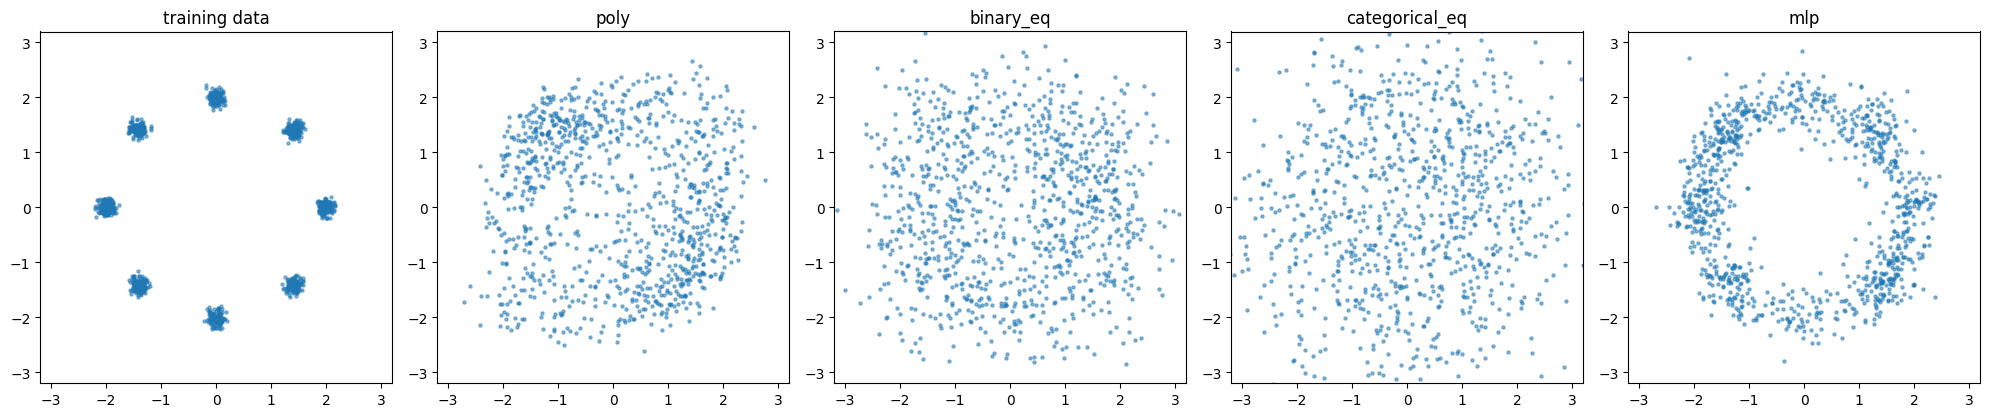

In [16]:

def plot_generated_samples(train_data, samples, max_points=1200):
    ncols = 1 + len(samples)
    fig, axes = plt.subplots(1, ncols, figsize=(4.0 * ncols, 4.0), squeeze=False)
    axes = axes[0]
    axes[0].scatter(np.asarray(train_data[:max_points, 0]), np.asarray(train_data[:max_points, 1]), s=5, alpha=0.5)
    axes[0].set_title("training data")
    axes[0].set_aspect("equal")
    for ax, (name, sx) in zip(axes[1:], samples.items()):
        arr = np.asarray(sx[:max_points])
        ax.scatter(arr[:, 0], arr[:, 1], s=5, alpha=0.5)
        ax.set_title(name)
        ax.set_aspect("equal")
    for ax in axes:
        ax.set_xlim(-GRID_LIM, GRID_LIM)
        ax.set_ylim(-GRID_LIM, GRID_LIM)
    plt.tight_layout()
    plt.show()

plot_generated_samples(train_data, samples)



## Energy landscapes and force fields

The polynomial, binary, and categorical models expose an energy/free-energy.  The MLP only exposes a force field.  The final panel is the exact empirical energy for reference.


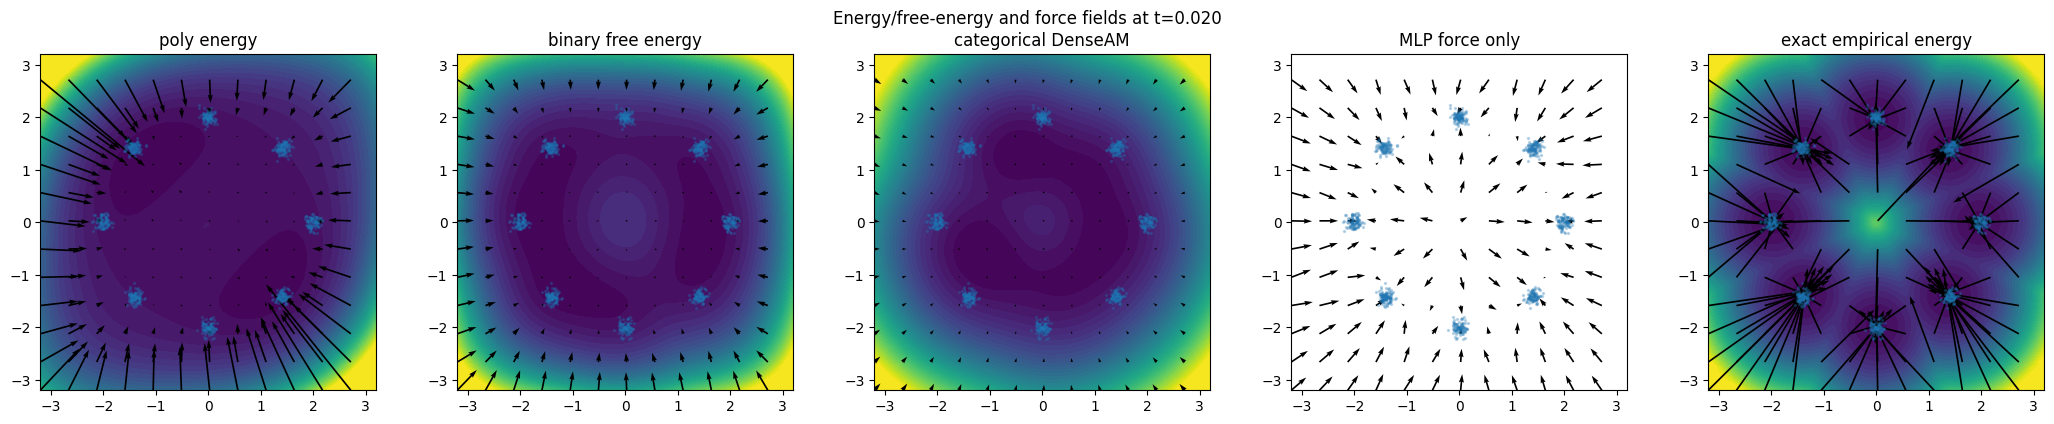

In [17]:

def make_grid(grid_lim=GRID_LIM, grid_n=GRID_N):
    xs = jnp.linspace(-grid_lim, grid_lim, grid_n)
    ys = jnp.linspace(-grid_lim, grid_lim, grid_n)
    X, Y = jnp.meshgrid(xs, ys)
    pts = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
    return X, Y, pts


def plot_energy_and_force(t_plot=T_MIN, quiver_stride=10):
    X, Y, pts = make_grid()
    panels = []
    if "poly" in trained:
        p = trained["poly"][nearest_time_idx(t_plot)]
        panels.append(("poly energy", poly_energy(p, pts), poly_force(p, pts)))
    if "binary" in trained:
        p = trained["binary"][nearest_time_idx(t_plot)]
        panels.append(("binary free energy", binary_energy(p, pts), binary_force(p, pts)))
    if "categorical" in trained:
        p = trained["categorical"][nearest_time_idx(t_plot)]
        panels.append(("categorical DenseAM", cat_energy(p, pts), cat_force(p, pts)))
    if "mlp" in trained:
        panels.append(("MLP force only", None, mlp_force(trained["mlp"], pts, jnp.ones((pts.shape[0],)) * t_plot)))
    panels.append(("exact empirical energy", empirical_energy(pts, t_plot, train_data, min(2048, train_data.shape[0]), kBT), empirical_force(pts, t_plot, train_data, min(2048, train_data.shape[0]), kBT)))

    fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4.1), squeeze=False)
    axes = axes[0]
    for ax, (title, energy, force) in zip(axes, panels):
        if energy is not None:
            Z = np.asarray(energy).reshape(X.shape)
            # Robust clipping makes contours readable.
            lo, hi = np.percentile(Z, [2, 98])
            ax.contourf(np.asarray(X), np.asarray(Y), np.clip(Z, lo, hi), levels=40)
        F = np.asarray(force).reshape(X.shape + (2,))
        sl = slice(None, None, quiver_stride)
        ax.quiver(np.asarray(X)[sl, sl], np.asarray(Y)[sl, sl], F[sl, sl, 0], F[sl, sl, 1], angles="xy", scale_units="xy", scale=18)
        ax.scatter(np.asarray(train_data[:800, 0]), np.asarray(train_data[:800, 1]), s=2, alpha=0.25)
        ax.set_title(title)
        ax.set_aspect("equal")
        ax.set_xlim(-GRID_LIM, GRID_LIM)
        ax.set_ylim(-GRID_LIM, GRID_LIM)
    plt.suptitle(f"Energy/free-energy and force fields at t={t_plot:.3f}")
    plt.tight_layout()
    plt.show()

plot_energy_and_force(T_MIN)



## Hidden time-scale sensitivity

For the binary and categorical latent models, the previous sampler assumes infinitely fast hidden units.  Here the hidden variables are dynamical and relax with a finite time constant.  `hidden_tau_ratio=0` means instantaneous equilibration.  Values near `0.01`--`0.05` are fast compared with the visible drift; values near `0.5`--`1.0` are slow and should often degrade generation.


{'model': 'binary', 'tau_ratio': 0.0, 'coverage': 1.0, 'kl_to_uniform': 0.005642619866700199, 'mean_nearest_dist': 0.6928109526634216}
{'model': 'binary', 'tau_ratio': 0.01, 'coverage': 1.0, 'kl_to_uniform': 0.004205406720842393, 'mean_nearest_dist': 0.7335519194602966}
{'model': 'binary', 'tau_ratio': 0.05, 'coverage': 1.0, 'kl_to_uniform': 0.013717624303984875, 'mean_nearest_dist': 0.7210965752601624}
{'model': 'binary', 'tau_ratio': 0.1, 'coverage': 1.0, 'kl_to_uniform': 0.008426399557977297, 'mean_nearest_dist': 0.7608964443206787}
{'model': 'binary', 'tau_ratio': 0.5, 'coverage': 1.0, 'kl_to_uniform': 0.00448338945590087, 'mean_nearest_dist': 0.9440858960151672}
{'model': 'binary', 'tau_ratio': 1.0, 'coverage': 1.0, 'kl_to_uniform': 0.0029889413444650955, 'mean_nearest_dist': 0.9916450381278992}
{'model': 'categorical', 'tau_ratio': 0.0, 'coverage': 1.0, 'kl_to_uniform': 0.005711472571764548, 'mean_nearest_dist': 0.8265320658683777}
{'model': 'categorical', 'tau_ratio': 0.01, 'cov

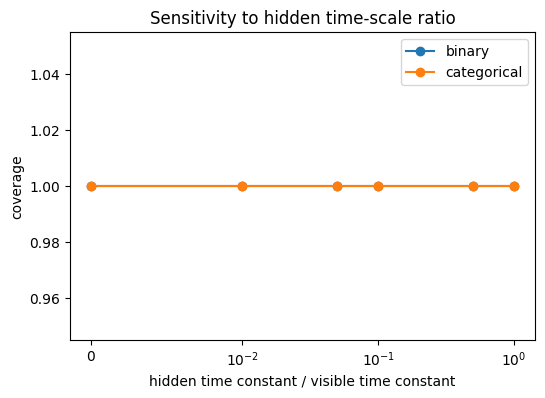

In [18]:

def hidden_timescale_sweep(key, ratios=(0.0, 0.01, 0.05, 0.1, 0.5, 1.0), n_samples=800):
    rows = []
    sweep_samples = {}
    if "binary" in trained:
        for r in ratios:
            key, sub = random.split(key)
            sx, key = reverse_sample_binary_finite_hidden(sub, trained["binary"], hidden_tau_ratio=r, n_samples=n_samples)
            sweep_samples[f"binary_tau={r:g}"] = sx
            m = coverage_metrics(sx, data_meta)
            rows.append({"model": "binary", "tau_ratio": r, **{k: v for k, v in m.items() if k != "counts"}})
    if "categorical" in trained:
        for r in ratios:
            key, sub = random.split(key)
            sx, key = reverse_sample_cat_finite_hidden(sub, trained["categorical"], hidden_tau_ratio=r, n_samples=n_samples)
            sweep_samples[f"cat_tau={r:g}"] = sx
            m = coverage_metrics(sx, data_meta)
            rows.append({"model": "categorical", "tau_ratio": r, **{k: v for k, v in m.items() if k != "counts"}})
    return rows, sweep_samples, key

key, sub = random.split(key)
time_rows, time_sweep_samples, key = hidden_timescale_sweep(sub)
for row in time_rows:
    print(row)

# Plot coverage versus hidden time-scale ratio.
if time_rows:
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    for model in sorted(set(r["model"] for r in time_rows)):
        rr = [r for r in time_rows if r["model"] == model]
        ax.plot([r["tau_ratio"] for r in rr], [r["coverage"] for r in rr], marker="o", label=model)
    ax.set_xscale("symlog", linthresh=0.01)
    ax.set_xlabel("hidden time constant / visible time constant")
    ax.set_ylabel("coverage")
    ax.set_title("Sensitivity to hidden time-scale ratio")
    ax.legend()
    plt.show()



## Optional: exact empirical-score oracle sampler

This is not a trainable physical model.  It uses the exact empirical score of the noisy training set and is useful as an upper-bound reference for whether the OU schedule and reverse sampler are working.


oracle metrics: {'coverage': 1.0, 'kl_to_uniform': 0.004720318993585439, 'mean_nearest_dist': 0.23589926958084106}


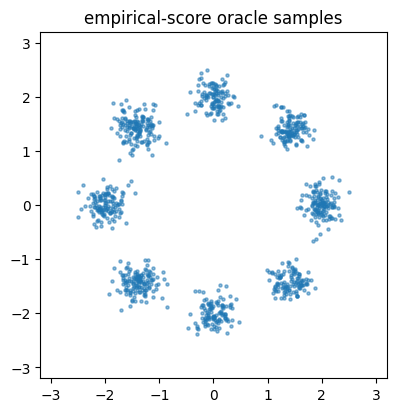

In [19]:

def reverse_sample_empirical_oracle(key, data, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS, max_data=2048, clip_x=8.0):
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        f = empirical_force(x, s, data, min(max_data, data.shape[0]), kBT)
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key

key, sub = random.split(key)
oracle_samples, key = reverse_sample_empirical_oracle(sub, train_data, n_samples=min(1000, N_SAMPLES))
print("oracle metrics:", {k: v for k, v in coverage_metrics(oracle_samples, data_meta).items() if k != "counts"})

plt.figure(figsize=(4.5, 4.5))
arr = np.asarray(oracle_samples)
plt.scatter(arr[:, 0], arr[:, 1], s=5, alpha=0.5)
plt.title("empirical-score oracle samples")
plt.gca().set_aspect("equal")
plt.xlim(-GRID_LIM, GRID_LIM)
plt.ylim(-GRID_LIM, GRID_LIM)
plt.show()



## Interpretation checklist

Use these diagnostics to decide whether latent DAM-style fast variables are buying you anything:

1. **Visible-only polynomial energy** should be the least expressive.  It can fit a few low-order geometric features but struggles with multimodal or curved manifolds unless the polynomial basis is very large.
2. **Binary hidden free energy** should increase expressivity through softplus-ridge components.  In hardware language, this is a restricted visible--hidden architecture; the hidden layer implements fast nonlinear basis selection.
3. **Categorical DenseAM/prototype model** should perform especially well on data distributions that are naturally described as mixtures or manifolds tiled by prototypes.  It is also closest to the log-sum-exp DAM/diffusion correspondence.
4. **MLP score network** is a useful ceiling for force-field approximation, but it is not an energy model unless explicitly constrained to be conservative.
5. **Hidden time-scale sweep** is the physical-reality test.  If quality collapses once hidden units are only moderately slower than instantaneous, then the architecture may require either faster hidden circuitry, smaller reverse-time steps, or a force law that is less sensitive to hidden lag.

For hardware-oriented follow-up, the most relevant comparison is usually categorical DenseAM versus binary-hidden free energy under finite hidden time scale.  The former has a direct crossbar interpretation as prototype similarity accumulation plus softmax/WTA competition; the latter resembles an RBM-style visible--hidden crossbar with nonlinear hidden activation.
